$n$個のデータ$(x_1,y_1),...(x_n,y_n)$が観測され、各$y_i$が #Suppose that n observations are obtained. For each observation i,

$$
y_i=\alpha +\beta x_i+u_i,\ i=1,...,n #Each observation is generated according to this linear regression model.

が得られます。 

最小二乗法による、#Using the least squares method, the regression coefficient can be estimated as follows:
$$
\hat{\beta}=\frac{\sum_{i=1}^n (x_i-\bar{x})(y_i-\bar{y})}{\sum_{i=1}^n (x_i-\bar{x})^2}=\frac{標本共分散(x_i,y_i)}{標本分散(x_i)} #estimated slope
$$

$$
\hat{\alpha}=\hat{y}-\hat{\beta}\bar{x} #estimated intercept
$$

で回帰モデルの係数を推定することができる。Each observation is generated according to this linear regression model.

以下は、仮想データを作成し、回帰モデルの係数推定式によって計算した結果が真の値にどれほど近づくかを検証するためのコードである
このコードに基づいて、課題に解答しなさい。

The following code creates artificial data and examines how closely the estimated regression coefficients approach the true values. Answer the exercises based on this code.

In [15]:
# 線形回帰モデルのデータをシミュレーションで生成します Generate data for a linear regression model using simulation.

import numpy as np

# サンプルデータ Sample data
# パラメータ Parameters
beta_0 = 2.5  # 切片 Intercept
beta_1 = 0.8  # 傾き Slope
n = 100  # データ数 Number of data points/sample size 

# 説明変数を一様分布から生成 Generate the explanatory variable from a uniform distribution.
x = np.random.uniform(low=0, high=10, size=n) #explanatory variable, values randomly generated between 0 and 10. 

# ノイズ項を標準正規分布から生成 Generate the noise (error) term from a standard normal distribution.
epsilon = np.random.normal(loc=0, scale=1, size=n)

# 目的変数を生成 Generate the dependent (response) variable.
y = beta_0 + beta_1 * x + epsilon #random noise is added to the linear relationship between x and y, with average value/mean of 0 and standard deviation of 1.

In [16]:
# パラメータの推定 Parameter estimation
x_mean = np.mean(x)
y_mean = np.mean(y)

# β₁の推定 Parameter estimation for β₁
numerator = np.sum((x - x_mean) * (y - y_mean))
denominator = np.sum((x - x_mean) ** 2)
beta = numerator / denominator
print("beta: ", beta)
# β₀の推定 Parameter estimation for β₀
alpha = y_mean - beta * x_mean

print("alpha: ", alpha)

beta:  0.7904318487496607
alpha:  2.601834984043886


# 課題1

母集団回帰係数、誤差項とサンプルサイズを指定し、観測データ($x$,$y$)を生成する関数を作成しなさい

Task 1.
Create a function that generates observed data (x,y) by specifying the population regression coefficients, the error term, and the sample size.

In [ ]:
import numpy as np

def generate_data(beta_0, beta_1, error_std, n):

    # Generate the explanatory variable x
    x = np.random.uniform(
        low=0,
        high=10,
        size=n
    )

    # Generate the random error term
    epsilon = np.random.normal(
        loc=0,
        scale=error_std,
        size=n
    )

    # Generate the response/dependent variable y
    y = beta_0 + beta_1 * x + epsilon

    return x, y

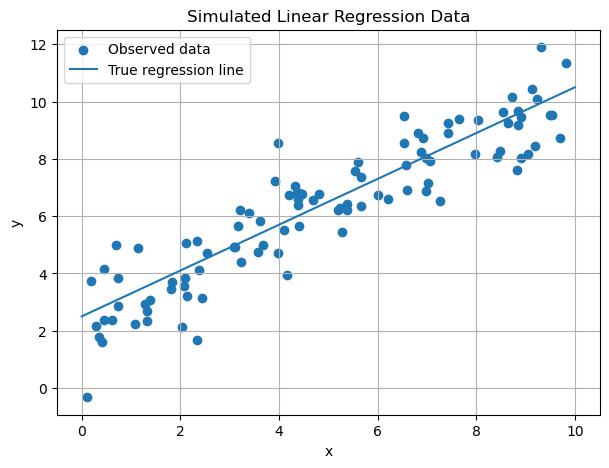

In [18]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(1000)

x, y = generate_data(
    beta_0=2.5,
    beta_1=0.8,
    error_std=1,
    n=100
)

plt.figure(figsize=(7,5))

# Scatter plot of the generated data
plt.scatter(x, y, label="Observed data")

# True regression line
x_line = np.linspace(0, 10, 100)
y_line = 2.5 + 0.8 * x_line

plt.plot(x_line, y_line, label="True regression line")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Simulated Linear Regression Data")

plt.legend()
plt.grid(True)

plt.show()

The simulated data show a positive linear relationship between x and y, with observations scattered around the true regression line. 

# 課題2

観測データ($x$,$y$)で、最小二乗法で回帰係数を推定する関数を作成しなさい

Task 2.
Create a function that estimates the regression coefficients from the observed data (x,y) using the least squares method. #The purpose of the least squares method is to find the line that minimizes the Residual Sum of Squares (RSS). These formulas are the solution to the optimization problem of minimizing the RSS. 

In [ ]:
def estimate_coefficients(x, y): #define a function to estimate the coefficients of a linear regression model given the explanatory variable x and the response variable y.

    # Calculate the sample means
    x_mean = np.mean(x) #determine the average value/mean of the explanatory variable x.
    y_mean = np.mean(y) #determine the average value/mean of the response variable y.

    # Calculate the numerator of the slope formula
    numerator = np.sum(
        (x - x_mean) * (y - y_mean)
    ) 

    # Calculate the denominator of the slope formula
    denominator = np.sum(
        (x - x_mean) ** 2
    )

    # Estimate the slope
    beta_hat = numerator / denominator

    # Estimate the intercept
    alpha_hat = y_mean - beta_hat * x_mean

    return alpha_hat, beta_hat


In [20]:
alpha_hat, beta_hat = estimate_coefficients(x, y)

print("Estimated intercept:", alpha_hat)
print("Estimated slope:", beta_hat)

Estimated intercept: 2.3514231042738962
Estimated slope: 0.8037365872499442


In [21]:
print("True intercept:", 2.5)
print("Estimated intercept:", alpha_hat)

print("True slope:", 0.8)
print("Estimated slope:", beta_hat)

True intercept: 2.5
Estimated intercept: 2.3514231042738962
True slope: 0.8
Estimated slope: 0.8037365872499442


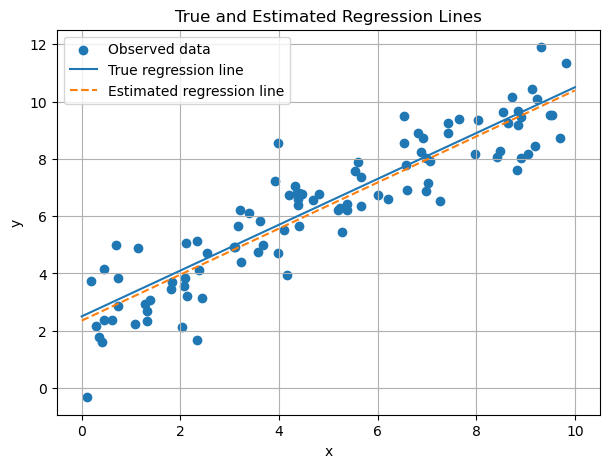

In [22]:
import matplotlib.pyplot as plt

# Estimate coefficients
alpha_hat, beta_hat = estimate_coefficients(x, y)

# Values for drawing the lines
x_line = np.linspace(0, 10, 100)

# True regression line
y_true_line = 2.5 + 0.8 * x_line

# Estimated regression line
y_estimated_line = alpha_hat + beta_hat * x_line

plt.figure(figsize=(7, 5))

plt.scatter(x, y, label="Observed data")

plt.plot(
    x_line,
    y_true_line,
    label="True regression line"
)

plt.plot(
    x_line,
    y_estimated_line,
    linestyle="--",
    label="Estimated regression line"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("True and Estimated Regression Lines")
plt.legend()
plt.grid(True)

plt.show()

The estimated regression line closely matches the true regression line, which indicates that the least squares method successfully estimated the underlying regression coefficients from the simulated data.

# 課題3

- 一定な母集団回帰係数、誤差項サンプルサイズを設定し、観測データを作成し、回帰係数を推定するといった推定プロセスを100回を行いなさい。
- 毎回の推定値を格納し、その平均と標準偏差を計算しなさい。
- サンプルサイズが $20, 50, 100, 200, 500,1000$である場合、推定値の平均と標準偏差を比較しなさい

Task 3.
Set fixed population regression coefficients, an error term, and a sample size. Repeat the following estimation process 100 times:
Generate observed data.
- Estimate the regression coefficients.
- Store the estimated values.
- Calculate the mean and standard deviation of the estimates.
- Compare the means and standard deviations of the estimates for different sample sizes.


In [23]:
def repeat_estimation(beta_0, beta_1, error_std, n, repetitions=1000):

    # Store the estimated intercepts
    alpha_estimates = []

    # Store the estimated slopes
    beta_estimates = []

    # Repeat the estimation process
    for _ in range(repetitions):

        # Generate a new dataset
        x, y = generate_data(
            beta_0,
            beta_1,
            error_std,
            n
        )

        # Estimate the coefficients
        alpha_hat, beta_hat = estimate_coefficients(x, y)

        # Save the estimates
        alpha_estimates.append(alpha_hat)
        beta_estimates.append(beta_hat)

    # Calculate the summary statistics
    alpha_mean = np.mean(alpha_estimates)
    alpha_std = np.std(alpha_estimates, ddof=1)

    beta_mean = np.mean(beta_estimates)
    beta_std = np.std(beta_estimates, ddof=1)

    # Return all results
    return (
        alpha_estimates,
        beta_estimates,
        alpha_mean,
        alpha_std,
        beta_mean,
        beta_std
    )

In [26]:
beta_0 = 2.5
beta_1 = 0.8
error_std = 1
n = 20

results = repeat_estimation(
    beta_0,
    beta_1,
    error_std,
    n
)

alpha_estimates, beta_estimates, alpha_mean, alpha_std, beta_mean, beta_std = results

print("Mean of estimated intercept:", alpha_mean)
print("Standard deviation of estimated intercept:", alpha_std)

print("Mean of estimated slope:", beta_mean)
print("Standard deviation of estimated slope:", beta_std)

Mean of estimated intercept: 2.489951505784792
Standard deviation of estimated intercept: 0.46840790217987016
Mean of estimated slope: 0.8031430178478675
Standard deviation of estimated slope: 0.08140239316195444


In [29]:
beta_0 = 2.5
beta_1 = 0.8
error_std = 1
n = 50

results = repeat_estimation(
    beta_0,
    beta_1,
    error_std,
    n
)

alpha_estimates, beta_estimates, alpha_mean, alpha_std, beta_mean, beta_std = results

print("Mean of estimated intercept:", alpha_mean)
print("Standard deviation of estimated intercept:", alpha_std)

print("Mean of estimated slope:", beta_mean)
print("Standard deviation of estimated slope:", beta_std)

Mean of estimated intercept: 2.48515781031558
Standard deviation of estimated intercept: 0.29030474491981484
Mean of estimated slope: 0.8028616502025038
Standard deviation of estimated slope: 0.050264487857653466


In [32]:
beta_0 = 2.5
beta_1 = 0.8
error_std = 1
n = 100

results = repeat_estimation(
    beta_0,
    beta_1,
    error_std,
    n
)

alpha_estimates, beta_estimates, alpha_mean, alpha_std, beta_mean, beta_std = results

print("Mean of estimated intercept:", alpha_mean)
print("Standard deviation of estimated intercept:", alpha_std)

print("Mean of estimated slope:", beta_mean)
print("Standard deviation of estimated slope:", beta_std)

Mean of estimated intercept: 2.4940841910889184
Standard deviation of estimated intercept: 0.20536383392361787
Mean of estimated slope: 0.8008394748071159
Standard deviation of estimated slope: 0.035473215911698025


In [33]:
beta_0 = 2.5
beta_1 = 0.8
error_std = 1
n = 200

results = repeat_estimation(
    beta_0,
    beta_1,
    error_std,
    n
)

alpha_estimates, beta_estimates, alpha_mean, alpha_std, beta_mean, beta_std = results

print("Mean of estimated intercept:", alpha_mean)
print("Standard deviation of estimated intercept:", alpha_std)

print("Mean of estimated slope:", beta_mean)
print("Standard deviation of estimated slope:", beta_std)

Mean of estimated intercept: 2.500724587138212
Standard deviation of estimated intercept: 0.14238410305368926
Mean of estimated slope: 0.7999425115961576
Standard deviation of estimated slope: 0.02489739884450309


In [34]:
beta_0 = 2.5
beta_1 = 0.8
error_std = 1
n = 500

results = repeat_estimation(
    beta_0,
    beta_1,
    error_std,
    n
)

alpha_estimates, beta_estimates, alpha_mean, alpha_std, beta_mean, beta_std = results

print("Mean of estimated intercept:", alpha_mean)
print("Standard deviation of estimated intercept:", alpha_std)

print("Mean of estimated slope:", beta_mean)
print("Standard deviation of estimated slope:", beta_std)

Mean of estimated intercept: 2.499600226035241
Standard deviation of estimated intercept: 0.0897224164731662
Mean of estimated slope: 0.7999587339190398
Standard deviation of estimated slope: 0.015659496787692465


In [35]:
beta_0 = 2.5
beta_1 = 0.8
error_std = 1
n = 1000

results = repeat_estimation(
    beta_0,
    beta_1,
    error_std,
    n
)

alpha_estimates, beta_estimates, alpha_mean, alpha_std, beta_mean, beta_std = results

print("Mean of estimated intercept:", alpha_mean)
print("Standard deviation of estimated intercept:", alpha_std)

print("Mean of estimated slope:", beta_mean)
print("Standard deviation of estimated slope:", beta_std)

Mean of estimated intercept: 2.499154751845612
Standard deviation of estimated intercept: 0.06394699745888852
Mean of estimated slope: 0.8002374824705316
Standard deviation of estimated slope: 0.01101519580589604


In [49]:
import numpy as np
import pandas as pd

def repeat_estimation(beta_0, beta_1, error_std, n, repetitions=1000):

    alpha_estimates = []
    beta_estimates = []

    for _ in range(repetitions):

        # Generate data
        x, y = generate_data(
            beta_0,
            beta_1,
            error_std,
            n
        )

        # Estimate coefficients
        alpha_hat, beta_hat = estimate_coefficients(x, y)

        # Store estimates
        alpha_estimates.append(alpha_hat)
        beta_estimates.append(beta_hat)

    # Return summary statistics
    return {
        "Sample Size": n,
        "Mean Intercept": np.mean(alpha_estimates),
        "SD Intercept": np.std(alpha_estimates, ddof=1),
        "Mean Slope": np.mean(beta_estimates),
        "SD Slope": np.std(beta_estimates, ddof=1)
    }


# Population parameters

beta_0 = 2.5
beta_1 = 0.8
error_std = 1

sample_sizes = [20, 50, 100, 200, 500, 1000]

results_table = []

# Run simulation for every sample size
for n in sample_sizes:

    result = repeat_estimation(
        beta_0,
        beta_1,
        error_std,
        n,
        repetitions=100
    )

    results_table.append(result)

# Convert to table
results_df = pd.DataFrame(results_table)

# Display the table
print(results_df)

   Sample Size  Mean Intercept  SD Intercept  Mean Slope  SD Slope
0           20        2.507207      0.506562    0.800019  0.091190
1           50        2.524766      0.305349    0.796978  0.051142
2          100        2.492930      0.211123    0.800870  0.036837
3          200        2.519557      0.140196    0.795547  0.022801
4          500        2.507660      0.092154    0.800483  0.015701
5         1000        2.491951      0.070625    0.801705  0.012651


The estimated intercepts and slopes remain close to the true population values of 2.5 and 0.8, respectively, for all sample sizes. This indicates that the least squares estimator provides accurate estimates of the regression coefficients. As the sample size increases from 20 to 1000, the standard deviations of both the intercept and slope estimates decrease substantially. For example, the standard deviation of the estimated slope decreases from 0.0912 to 0.0127, while the standard deviation of the estimated intercept decreases from 0.5066 to 0.0706. This demonstrates that larger sample sizes produce more precise and stable estimates because the sampling variability becomes smaller.